# `PaperFig04.m` → Python: 수식 중심 단계별 튜토리얼

이 노트북은 `ref/code/PaperFig04.m`을 단순 문법 치환하지 않고, **각 MATLAB 블록이 구현하는 수학 모델을 먼저 쓰고 Python으로 옮기는 방식**으로 설명합니다. Figure 4의 10 Gy, 50%/100% 조사 시뮬레이션을 한 번에 재현하며, 원본에 없는 측정 데이터 점은 만들지 않습니다.

핵심 목표는 다음과 같습니다.

1. MATLAB 원본의 줄 범위와 Python 셀을 대응시킨다.
2. 종양 생존, 면역 활성화, CTL, doomed-cell 재귀식을 LaTeX로 명확히 적는다.
3. MATLAB의 1-based 인덱싱을 Python의 0-based 인덱싱으로 정확히 바꾼다.
4. 원본처럼 한 조건씩 다시 실행하지 않고 50%와 100% 조사를 함수로 비교한다.

> 기준 소스: `ref/code/PaperFig04.m` (Cho et al., 2023 Figure 4 생성 코드)

## 0. 원본 코드의 전체 구조

| MATLAB 줄 | 역할 | 이 노트북 |
|---:|---|---|
| 13–33 | 방사선·면역 파라미터와 Figure 4 override | §2 |
| 37–42 | 평형 부피와 bifurcation 근사량 | §3 |
| 44–77, 243–262 | DVH 파일 탐색과 파싱 | §4 |
| 87–97 | 시간축과 조사 스케줄 | §5 |
| 98–112 | LQ 생존분율과 지연 사멸 | §6 |
| 115–130 | 상태 배열과 초기조건 | §7 |
| 145–167 | 하루 단위 재귀 모델 | §8 |
| 170–225 | Figure 4 형태의 그래프 | §10 |

원본 MATLAB 파일은 한 번 실행할 때 한 coverage만 계산합니다. 주석 처리된 dose 줄을 바꾸어 50%와 100% 조건을 따로 실행해야 합니다. Python 버전은 동일한 재귀식을 `simulate_fig4(..., coverage=...)`로 묶어 두 조건을 명시적으로 계산합니다.

## 1. 상태변수와 인덱스 정의

시간은 일(day) 단위의 이산 인덱스 $n=0,1,\ldots,N-1$, 공간/DVH 구간은 $j=1,\ldots,M$로 둡니다.

| 기호 | MATLAB | 의미 |
|---|---|---|
| $T_{n,j}$ | `T(day,j)` | 살아 있는 종양 부피 |
| $D_{n,j}$ | `D(day,j)` | 치명 손상 후 아직 제거되지 않은 종양 부피 |
| $L_{n,j}$ | `Ln(day,j)` | 활성 CTL/lymphocyte 양 |
| $A_{n,j}$ | `DC(day,j)` | 면역 triggering cell의 상대 밀도 |
| $Z^p_n$ | `Zp(day)` | primary immune effect |
| $Z^s_n$ | `Zs(day)` | secondary/memory immune effect |
| $\varepsilon_n$ | `eps(day)` | 방사선 손상에 의한 CTL activation fraction |

관측 종양 부피는 viable cell과 doomed cell의 합입니다.

$$
V_n = \sum_{j=1}^{M}\left(T_{n,j}+D_{n,j}\right).\tag{1}
$$

면역 효과는 모든 공간 구간에 공통으로 작용한다고 가정합니다.

$$
Z_n = Z^p_n + Z^s_n.\tag{2}
$$

In [1]:
from dataclasses import asdict, dataclass
from pathlib import Path
import re

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

plt.style.use('seaborn-v0_8-whitegrid')
pd.set_option('display.precision', 6)

## 2. 파라미터: MATLAB 13–33줄

원본에서는 먼저 일반값을 넣은 뒤 Figure 4 값으로 여러 번 덮어씁니다. 예를 들어 `Psi`는 1300 → 200 → **300**, `rho`는 0.1 → **0.5**, `omega`는 0.05 → **0.135**, `k`는 0 → **1.1**이 됩니다. 아래 dataclass에는 실제 시뮬레이션에 사용되는 **최종값만** 적어 덮어쓰기의 모호성을 제거합니다.

종양 성장률과 하루 단위 제거율은

$$
\mu=\frac{\ln 2}{T_{\mathrm{pot}}},\qquad
\lambda(T_{1/2})=1-\exp\!\left(-\frac{\ln 2}{T_{1/2}}\right).\tag{3}
$$

여기서는 $T_{\mathrm{pot}}=3.2\,\mathrm{day}$, 세 decay/recovery half-life는 모두 15 day입니다. `gamma=0`이므로 Figure 4에서는 secondary response가 발생하지 않습니다.

In [2]:
@dataclass(frozen=True)
class Fig4Parameters:
    # LQ radiosensitivity [Gy^-1, Gy^-2]
    alpha_t: float = 0.05
    beta_t: float = 0.05 / 4.4
    alpha_l: float = 0.182
    beta_l: float = 0.143

    # Growth, decay, and immune parameters [day^-1 where applicable]
    mu: float = np.log(2.0) / 3.2
    lambda_t: float = 1.0 - np.exp(-np.log(2.0) / 15.0)
    lambda_a: float = 1.0 - np.exp(-np.log(2.0) / 15.0)
    lambda_l: float = 1.0 - np.exp(-np.log(2.0) / 15.0)
    rho: float = 0.5
    psi: float = 300.0
    omega: float = 0.135
    gamma: float = 0.0
    r: float = 5.0
    kappa: float = 1.1

    # Treatment and numerical grid
    initial_volume: float = 0.03
    treatment_day: int = 10
    dose_gy: float = 10.0
    n_days: int = 901
    n_bins: int = 100
    clearance_mean_days: float = 3.0
    clearance_std_days: float = 1.5
    activation_sensitivity: float = 1.0
    p1: float = 0.0
    c4: float = 0.0


params = Fig4Parameters()
pd.DataFrame({'parameter': asdict(params).keys(), 'value': asdict(params).values()})

,parameter,value
0,alpha_t,0.050000
1,beta_t,0.011364
2,alpha_l,0.182000
3,beta_l,0.143000
4,mu,0.216608
5,lambda_t,0.045158
6,lambda_a,0.045158
7,lambda_l,0.045158
8,rho,0.500000
9,psi,300.000000


## 3. 평형·bifurcation 진단식: MATLAB 37–42줄

이 값들은 Figure 4의 재귀 계산 자체에는 직접 들어가지 않지만 모델의 동작 영역을 해석하는 기준입니다. 방사선과 immune suppression이 없는 단순 평형에서

$$
T_\infty=\frac{\lambda_L\mu}{\omega\rho},\qquad
D_\infty=\frac{\lambda_L}{\lambda_T}\left(e^\mu-1\right)\frac{\mu}{\omega\rho}.\tag{4}
$$

원본 코드가 `alpha`라고 부르는 bifurcation 보조량은 LQ 모델의 $\alpha_T$와 다른 값이므로 여기서는 $a_b$라고 씁니다.

$$
a_b=\left(\frac{1-\mu}{2.5}\right)^{2/3}\frac{1.5+\mu}{2.5},\qquad
\widehat\kappa=\frac{a_b\omega}{\mu T_\infty^{2/3}}.\tag{5}
$$

MATLAB의 `eps_k`가 바로 $\widehat\kappa$입니다. `max_T_inf`와 `T_inf_delta`도 원본 수식을 그대로 계산하되, 이는 근사적인 경계 진단값이라는 점에 주의합니다.

In [3]:
def equilibrium_diagnostics(p: Fig4Parameters) -> pd.Series:
    t_inf = p.lambda_l * p.mu / (p.omega * p.rho)
    d_inf = (p.lambda_l / p.lambda_t) * (np.exp(p.mu) - 1.0) * p.mu / (p.omega * p.rho)
    a_b = ((1.0 - p.mu) / 2.5) ** (2.0 / 3.0) * (1.5 + p.mu) / 2.5
    kappa_hat = a_b * p.omega / (p.mu * t_inf ** (2.0 / 3.0))
    max_t_inf = t_inf * (kappa_hat / (a_b * (p.kappa + 1e-9))) ** 1.5
    t_inf_delta = (9.0 - 22.0 * a_b) / (9.0 - 25.0 * a_b) * t_inf
    return pd.Series({
        'T_inf [cc]': t_inf,
        'D_inf [cc]': d_inf,
        'a_b': a_b,
        'kappa_hat': kappa_hat,
        'max_T_inf [cc]': max_t_inf,
        'T_inf_delta [cc]': t_inf_delta,
    })

equilibrium_diagnostics(params).to_frame('value')

,value
T_inf [cc],0.144914
D_inf [cc],0.776125
a_b,0.316780
kappa_hat,0.715608
max_T_inf [cc],0.426480
T_inf_delta [cc],0.272370


## 4. DVH 읽기: MATLAB 44–77, 243–262줄

원본은 Windows 경로에서 `*.dvh` 파일을 찾고 파일명 끝의 `D05`를 골라, `Points[]` 아래의 `(dose, dV)`를 읽습니다. dose는 cGy에서 Gy로 변환한 뒤 마지막 non-zero-volume dose로 정규화합니다.

Figure 4 코드의 활성 줄은 이후 `dose(day_SFRT+1,:)=10`으로 모든 구간의 dose를 10 Gy로 덮어씁니다. 따라서 DVH가 실제로 제공하는 정보 중 활성 시뮬레이션에 남는 것은 **공간 구간 수와 초기 부피 가중치 `dV/sum(dV)`**뿐입니다. 이 저장소에는 해당 `.dvh`가 없으므로 아래 parser는 정의만 하고, 실행 예제에서는 100개 동일 부피 구간을 사용합니다. 측정 데이터나 DVH를 임의로 만들지는 않습니다.

In [4]:
def read_dvh(path: str | Path) -> np.ndarray:
    """Return a (NumberOfPoints, 2) array of [dose_cGy, differential_volume_cc]."""
    path = Path(path)
    lines = path.read_text(encoding='utf-8', errors='replace').splitlines()
    number_of_points = None

    for line_index, line in enumerate(lines):
        key, separator, value = line.partition('=')
        if not separator:
            continue
        key = key.strip()
        if key == 'NumberOfPoints':
            number_of_points = int(value.strip().rstrip(';'))
        elif key == 'Points[]':
            if number_of_points is None:
                raise ValueError(f'NumberOfPoints must precede Points[] in {path}')
            point_lines = lines[line_index + 1:line_index + 1 + number_of_points]
            points = np.array([
                [float(piece) for piece in point_line.split(',')[:2]]
                for point_line in point_lines
            ])
            if points.shape != (number_of_points, 2):
                raise ValueError(f'Expected {number_of_points} DVH points in {path}')
            return points

    raise ValueError(f'Points[] section not found in {path}')


def load_depth_5cm_dvh(directory: str | Path) -> tuple[np.ndarray, np.ndarray]:
    """Translate the D05 filename selection and dose normalization in lines 62-77."""
    candidates = []
    for path in Path(directory).glob('*.dvh'):
        match = re.search(r'D(\d{2})\.dvh$', path.name, flags=re.IGNORECASE)
        if match and int(match.group(1)) == 5:
            candidates.append(path)
    if not candidates:
        raise FileNotFoundError(f'No depth-5 DVH file found in {directory}')

    dvh = read_dvh(sorted(candidates)[0])
    dose_gy = dvh[:, 0] / 100.0
    differential_volume = dvh[:, 1]
    positive = np.flatnonzero(differential_volume > 0.0)
    if positive.size == 0:
        raise ValueError('DVH has no positive differential-volume bins')
    normalized_dose = dose_gy / dose_gy[positive[-1]]
    return normalized_dose, differential_volume

## 5. 시간축과 50%/100% dose schedule: MATLAB 87–97줄

MATLAB의 `days = 0:900`은 Python의 `np.arange(901)`입니다. 가장 중요한 인덱스 변환은 다음과 같습니다.

| MATLAB | Python | 물리적 의미 |
|---|---|---|
| `T(1,:)` | `t[0, :]` | day 0 상태 |
| `dose(day_SFRT+1,:)` | `dose[treatment_day, :]` | day 10에서 다음 날로 넘어가는 조사 |
| `for day=1:days(end)` | `for n in range(n_days-1)` | 900개 상태 전이 |
| `i=day+1` | `next_n=n+1` | 다음 상태 인덱스 |

공간적으로 균일한 bin을 사용하므로 coverage $c$에 대해 조사되는 bin 수는 $M_c=\mathrm{round}(cM)$입니다.

$$
d_{n,j}=\begin{cases}
10\ \mathrm{Gy}, & n=10\ \text{and}\ j<M_c,\\
0, & \text{otherwise}.
\end{cases}\tag{6}
$$

In [5]:
def build_dose_schedule(p: Fig4Parameters, coverage: float) -> np.ndarray:
    if not 0.0 <= coverage <= 1.0:
        raise ValueError('coverage must be between 0 and 1')
    dose = np.zeros((p.n_days, p.n_bins), dtype=float)
    covered_bins = int(round(coverage * p.n_bins))
    dose[p.treatment_day, :covered_bins] = p.dose_gy
    return dose


dose_50 = build_dose_schedule(params, coverage=0.5)
dose_100 = build_dose_schedule(params, coverage=1.0)
pd.DataFrame({
    'coverage': ['50%', '100%'],
    'irradiated_bins': [np.count_nonzero(dose_50[params.treatment_day]),
                        np.count_nonzero(dose_100[params.treatment_day])],
    'dose_per_irradiated_bin_Gy': [dose_50.max(), dose_100.max()],
})

,coverage,irradiated_bins,dose_per_irradiated_bin_Gy
0,50%,50,10.0
1,100%,100,10.0


## 6. LQ 생존분율과 delayed tumor death: MATLAB 98–112줄

### 6.1 즉시 방사선 hazard

각 구간의 LQ log-kill은

$$
H^T_{n,j}=\alpha_T d_{n,j}+\beta_T d_{n,j}^2,\qquad
H^L_{n,j}=\alpha_L d_{n,j}+\beta_L d_{n,j}^2.\tag{7}
$$

CTL과 triggering cell은 같은 날 손상된다고 가정하므로

$$
S^L_{n,j}=\exp\!\left(-H^L_{n,j}\right).\tag{8}
$$

### 6.2 종양 사멸의 시간 지연

원본은 평균 3 day, 표준편차 1.5 day인 정규밀도를 day grid에 평가합니다. $m\ge1$에서

$$
\widetilde w_m=\frac{1}{\sigma\sqrt{2\pi}}\exp\!\left[-\frac12\left(\frac{m-\bar t}{\sigma}\right)^2\right],\qquad
w_0=1-\sum_{m=1}^{N-1}\widetilde w_m.\tag{9}
$$

따라서 여러 조사일의 누적 지연 hazard와 종양 생존분율은 convolution으로

$$
\mathcal H^T_{n,j}=\sum_{\tau=0}^{n}H^T_{\tau,j}w_{n-\tau},\qquad
S^T_{n,j}=\exp\!\left(-\mathcal H^T_{n,j}\right).\tag{10}
$$

MATLAB의 중첩 곱셈 루프는 식 (10)을 직접 누적한 것이며, Python에서는 `np.convolve`로 같은 계산을 더 분명하게 표현할 수 있습니다.

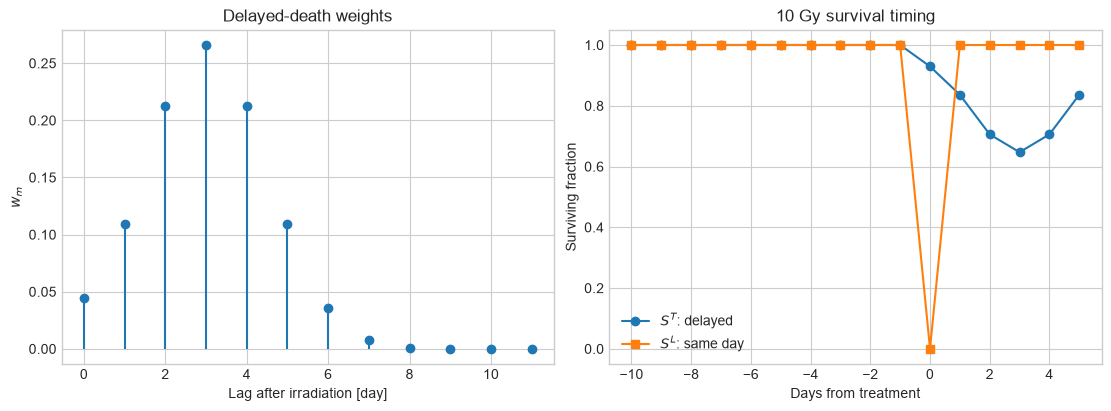

In [6]:
def normal_pdf(x: np.ndarray, mean: float, std: float) -> np.ndarray:
    return np.exp(-0.5 * ((x - mean) / std) ** 2) / (std * np.sqrt(2.0 * np.pi))


def clearance_weights(p: Fig4Parameters) -> np.ndarray:
    lag_days = np.arange(p.n_days, dtype=float)
    weights = normal_pdf(lag_days, p.clearance_mean_days, p.clearance_std_days)
    weights[0] = 1.0 - weights[1:].sum()  # exact translation of MATLAB line 101
    if weights[0] < 0.0 or not np.isclose(weights.sum(), 1.0):
        raise ValueError('The discretized clearance weights are not a probability distribution')
    return weights


def survival_fractions(dose: np.ndarray, p: Fig4Parameters) -> tuple[np.ndarray, np.ndarray]:
    tumor_hazard = p.alpha_t * dose + p.beta_t * dose**2
    weights = clearance_weights(p)
    sn_t = np.empty_like(tumor_hazard)
    for j in range(p.n_bins):
        delayed_hazard = np.convolve(tumor_hazard[:, j], weights, mode='full')[:p.n_days]
        sn_t[:, j] = np.exp(-delayed_hazard)
    lymphocyte_hazard = p.alpha_l * dose + p.beta_l * dose**2
    sn_l = np.exp(-lymphocyte_hazard)
    return sn_t, sn_l


weights = clearance_weights(params)
sn_t_100, sn_l_100 = survival_fractions(dose_100, params)

fig, axes = plt.subplots(1, 2, figsize=(11, 4), constrained_layout=True)
axes[0].stem(np.arange(12), weights[:12], basefmt=' ')
axes[0].set(xlabel='Lag after irradiation [day]', ylabel='$w_m$', title='Delayed-death weights')
axes[1].plot(np.arange(16) - params.treatment_day,
             sn_t_100[:16, 0], marker='o', label='$S^T$: delayed')
axes[1].plot(np.arange(16) - params.treatment_day,
             sn_l_100[:16, 0], marker='s', label='$S^L$: same day')
axes[1].set(xlabel='Days from treatment', ylabel='Surviving fraction', title='10 Gy survival timing')
axes[1].legend()
plt.show()

## 7. 상태 배열과 초기조건: MATLAB 115–130줄

초기 총 종양 부피는 0.03 cc이고, 원본은 DVH differential volume에 비례해 나눕니다.

$$
T_{0,j}=0.03\frac{\Delta V_j}{\sum_{q=1}^{M}\Delta V_q},\qquad
D_{0,j}=L_{0,j}=0,\qquad A_{0,j}=1.\tag{11}
$$

DVH가 없는 이 실행 예제에서는 $\Delta V_j$가 모두 같으므로 $T_{0,j}=0.03/M$입니다. `A=1`은 triggering cell density가 조사 전 포화 상태임을 뜻합니다.

## 8. 하루 단위 radio-immune 재귀식: MATLAB 145–167줄

아래 식은 코드가 계산하는 순서 그대로입니다. 먼저 현재 면역 효과를

$$Z_n=Z^p_n+Z^s_n\tag{12}$$

로 두고 viable tumor를 갱신합니다.

$$
T_{n+1,j}=T_{n,j}S^T_{n,j}\exp(\mu-Z_n).\tag{13}
$$

방사선으로 손상된 viable fraction이 전체 측정 부피에서 차지하는 비율로 activation을 계산합니다.

$$
\varepsilon_{n+1}=0.999\tanh\!\left[
s\,\frac{\sum_j(1-S^T_{n,j})T_{n,j}}{\sum_j(T_{n,j}+D_{n,j})}
\right].\tag{14}
$$

triggering-cell density $A$와 활성 CTL $L$은

$$
A_{n+1,j}=\left[\frac{S^L_{n,j}}{S^T_{n,j}}A_{n,j}
+\lambda_A(1-A_{n,j})\right](1-\varepsilon_{n+1}),\tag{15}
$$

$$
L_{n+1,j}=(1-\lambda_L)S^L_{n,j}L_{n,j}
+\rho T_{n+1,j}
+\psi\varepsilon_{n+1}A_{n+1,j}T_{n+1,j}.\tag{16}
$$

로 갱신됩니다. Primary/secondary immune effect는

$$
Z^p_{n+1}=\frac{\omega\sum_jL_{n+1,j}}{\displaystyle 1+\frac{\kappa(\sum_jT_{n+1,j})^{2/3}\sum_jL_{n+1,j}}{1+p_{n+1}}},\tag{17}
$$

$$
Z^s_{n+1}=Z^s_n+\gamma\frac{1+c_4}{r+c_4}Z^p_{n+1}.\tag{18}
$$

마지막으로 radiation kill과 immune kill로 생긴 doomed cell을 모읍니다.

$$
\begin{aligned}
D_{n+1,j}={}&(1-\lambda_T)D_{n,j}\\
&+(1-S^T_{n,j})T_{n,j}\\
&+S^T_{n,j}T_{n,j}e^\mu\left(1-e^{-Z_n}\right).
\end{aligned}\tag{19}
$$

식 (19)의 두 번째 항은 radiation-damaged tumor, 세 번째 항은 immune-killed tumor입니다. Figure 4에서는 $p_n=c_4=\gamma=0$이므로 checkpoint inhibitor와 memory response는 꺼져 있습니다.

In [7]:
@dataclass(frozen=True)
class Fig4Result:
    days: np.ndarray
    dose: np.ndarray
    sn_t: np.ndarray
    sn_l: np.ndarray
    viable: np.ndarray
    doomed: np.ndarray
    lymphocytes: np.ndarray
    triggering_cells: np.ndarray
    epsilon: np.ndarray
    z_primary: np.ndarray
    z_secondary: np.ndarray

    @property
    def total_volume(self) -> np.ndarray:
        return self.viable.sum(axis=1) + self.doomed.sum(axis=1)

    @property
    def immune_effect(self) -> np.ndarray:
        return self.z_primary + self.z_secondary


def simulate_fig4(
    p: Fig4Parameters,
    coverage: float,
    volume_weights: np.ndarray | None = None,
) -> Fig4Result:
    days = np.arange(p.n_days)
    dose = build_dose_schedule(p, coverage)
    sn_t, sn_l = survival_fractions(dose, p)

    if volume_weights is None:
        volume_weights = np.full(p.n_bins, 1.0 / p.n_bins)
    volume_weights = np.asarray(volume_weights, dtype=float)
    if volume_weights.shape != (p.n_bins,) or np.any(volume_weights < 0.0):
        raise ValueError(f'volume_weights must be a non-negative vector of length {p.n_bins}')
    if not np.isclose(volume_weights.sum(), 1.0):
        raise ValueError('volume_weights must sum to 1')

    t = np.zeros((p.n_days, p.n_bins))
    d = np.zeros_like(t)
    lymphocytes = np.zeros_like(t)
    triggering_cells = np.ones_like(t)
    epsilon = np.zeros(p.n_days)
    z_primary = np.zeros(p.n_days)
    z_secondary = np.zeros(p.n_days)
    t[0, :] = p.initial_volume * volume_weights

    for n in range(p.n_days - 1):
        next_n = n + 1
        z_now = z_primary[n] + z_secondary[n]

        t[next_n, :] = t[n, :] * sn_t[n, :] * np.exp(p.mu - z_now)

        measured_volume = max(np.sum(t[n, :] + d[n, :]), 1e-15)
        damaged_fraction = np.dot(1.0 - sn_t[n, :], t[n, :]) / measured_volume
        epsilon[next_n] = 0.999 * np.tanh(p.activation_sensitivity * damaged_fraction)

        triggering_cells[next_n, :] = (
            (sn_l[n, :] / sn_t[n, :]) * triggering_cells[n, :]
            + (1.0 - triggering_cells[n, :]) * p.lambda_a
        ) * (1.0 - epsilon[next_n])

        lymphocytes[next_n, :] = (
            (1.0 - p.lambda_l) * sn_l[n, :] * lymphocytes[n, :]
            + p.rho * t[next_n, :]
            + p.psi * epsilon[next_n] * triggering_cells[next_n, :] * t[next_n, :]
        )

        total_t = t[next_n, :].sum()
        total_l = lymphocytes[next_n, :].sum()
        suppression = 1.0 + p.kappa * total_t ** (2.0 / 3.0) * total_l / (1.0 + p.p1)
        z_primary[next_n] = p.omega * total_l / suppression
        z_secondary[next_n] = (
            z_secondary[n]
            + p.gamma * (1.0 + p.c4) / (p.r + p.c4) * z_primary[next_n]
        )

        d[next_n, :] = (
            (1.0 - p.lambda_t) * d[n, :]
            + (1.0 - sn_t[n, :]) * t[n, :]
            + sn_t[n, :] * t[n, :] * np.exp(p.mu) * (1.0 - np.exp(-z_now))
        )

    return Fig4Result(
        days=days, dose=dose, sn_t=sn_t, sn_l=sn_l, viable=t, doomed=d,
        lymphocytes=lymphocytes, triggering_cells=triggering_cells,
        epsilon=epsilon, z_primary=z_primary, z_secondary=z_secondary,
    )

## 9. 50%와 100% coverage 실행

동일한 파라미터와 동일한 초기 부피를 사용하고, 조사되는 공간 bin의 비율만 바꿉니다. 50% 조건은 절반의 종양·CTL·triggering cell을 직접 조사하고, 나머지 절반은 0 Gy입니다. 100% 조건은 모든 bin에 10 Gy를 조사합니다.

In [8]:
result_50 = simulate_fig4(params, coverage=0.5)
result_100 = simulate_fig4(params, coverage=1.0)

summary_days = np.array([0, 10, 20, 30, 60, 150])
pd.DataFrame({
    'day': summary_days,
    'day_from_treatment': summary_days - params.treatment_day,
    'V_50_cc': result_50.total_volume[summary_days],
    'V_100_cc': result_100.total_volume[summary_days],
    'Z_50': result_50.immune_effect[summary_days],
    'Z_100': result_100.immune_effect[summary_days],
})

,day,day_from_treatment,V_50_cc,V_100_cc,Z_50,Z_100
0,0,-10,0.030000,3.000000e-02,0.000000,0.000000
1,10,0,0.244481,2.444814e-01,0.053887,0.053887
2,20,10,0.525349,4.211266e-01,0.445507,0.270678
3,30,20,0.386990,3.805162e-01,0.706263,0.221337
4,60,50,0.097094,6.396759e-01,0.190630,0.123822
5,150,140,3.819864,4.692773e+06,0.062498,0.000004


### 계산 sanity check

아래 검사는 그래프 모양만 보고 넘어가지 않도록 배열 크기, 초기 부피, 조사 bin 수, 유한성, 비음수성, `gamma=0`일 때 secondary response가 0인지 확인합니다. 두 arm은 treatment가 적용되기 전까지 완전히 같아야 합니다. 마지막 검사는 convolution 구현을 MATLAB 103–106줄의 누적 곱셈 루프와 직접 비교합니다.

In [9]:
for result in (result_50, result_100):
    assert result.viable.shape == (params.n_days, params.n_bins)
    assert np.isclose(result.total_volume[0], params.initial_volume)
    assert np.all(np.isfinite(result.total_volume))
    assert np.all(result.viable >= 0.0)
    assert np.all(result.doomed >= 0.0)
    assert np.allclose(result.z_secondary, 0.0)

assert np.count_nonzero(result_50.dose[params.treatment_day]) == params.n_bins // 2
assert np.count_nonzero(result_100.dose[params.treatment_day]) == params.n_bins
assert np.allclose(
    result_50.total_volume[:params.treatment_day + 1],
    result_100.total_volume[:params.treatment_day + 1],
)
tumor_hazard = params.alpha_t * dose_100[:, 0] + params.beta_t * dose_100[:, 0]**2
sn_t_matlab_loop = np.ones(params.n_days)
for n in range(params.n_days - 1):
    sn_t_matlab_loop[n:] *= np.exp(
        -tumor_hazard[n] * weights[:params.n_days - n]
    )
assert np.allclose(sn_t_matlab_loop, result_100.sn_t[:, 0], rtol=1e-13, atol=1e-15)
print('All numerical sanity checks passed.')

All numerical sanity checks passed.


## 10. Figure 4 형태의 시각화: MATLAB 170–225줄

원본의 세 패널을 한 Figure에 그립니다.

- **(A)** primary immune effect $Z^p_n$과 성장률 $\mu$
- **(B)** 치료 후 0–30 day의 총 종양 부피 $V_n=T_n+D_n$
- **(C)** 치료 후 0–150 day extrapolation

점선 $V_0e^{\mu n}$은 면역효과와 방사선이 전혀 없는 단순 지수성장 기준선입니다. 원본의 panel A는 $Z^p$에는 `days-day_SFRT`, $\mu$ 선에는 `days`를 써 x축이 어긋나므로, 아래에서는 둘 다 치료일 기준 상대시간 $n-n_{\mathrm{RT}}$으로 통일했습니다.

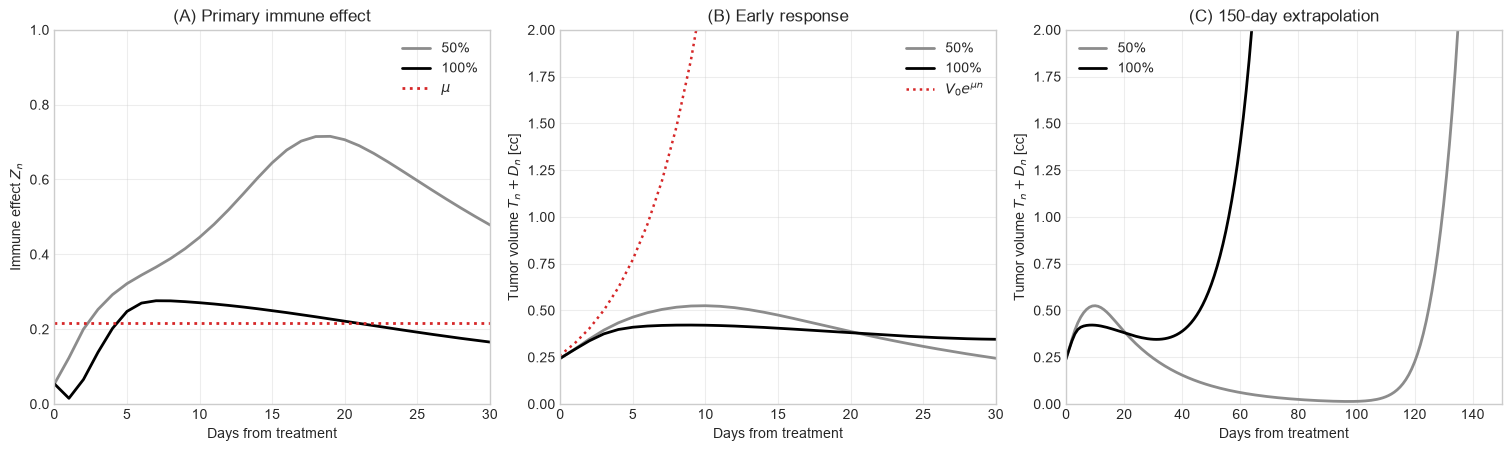

In [10]:
relative_days = result_50.days - params.treatment_day
exponential_control = params.initial_volume * np.exp(params.mu * result_50.days)
colors = {'50%': '0.55', '100%': 'black'}

fig, axes = plt.subplots(1, 3, figsize=(15, 4.4), constrained_layout=True)

for label, result in [('50%', result_50), ('100%', result_100)]:
    axes[0].plot(relative_days, result.z_primary, color=colors[label], lw=2, label=label)
axes[0].axhline(params.mu, color='tab:red', ls=':', lw=2, label=r'$\mu$')
axes[0].set(xlim=(0, 30), ylim=(0, 1), xlabel='Days from treatment',
            ylabel=r'Immune effect $Z_n$', title='(A) Primary immune effect')
axes[0].legend()

for label, result in [('50%', result_50), ('100%', result_100)]:
    axes[1].plot(relative_days, result.total_volume, color=colors[label], lw=2, label=label)
axes[1].plot(relative_days, exponential_control, color='tab:red', ls=':', lw=1.8, label=r'$V_0e^{\mu n}$')
axes[1].set(xlim=(0, 30), ylim=(0, 2), xlabel='Days from treatment',
            ylabel=r'Tumor volume $T_n+D_n$ [cc]', title='(B) Early response')
axes[1].legend()

for label, result in [('50%', result_50), ('100%', result_100)]:
    axes[2].plot(relative_days, result.total_volume, color=colors[label], lw=2, label=label)
axes[2].set(xlim=(0, 150), ylim=(0, 2), xlabel='Days from treatment',
            ylabel=r'Tumor volume $T_n+D_n$ [cc]', title='(C) 150-day extrapolation')
axes[2].legend()

for ax in axes:
    ax.grid(True, alpha=0.35)
plt.show()

## 11. 왜 partial irradiation의 장기 효과가 커질 수 있는가?

100% 조사는 초기 viable tumor를 더 많이 직접 손상시키지만, radiosensitivity가 큰 CTL과 triggering cell도 모두 손상시킵니다. 반면 50% 조사에서는 미조사 절반의 $L_{n,j}$와 $A_{n,j}$가 보존됩니다. 식 (16)의

$$\psi\varepsilon_{n+1}A_{n+1,j}T_{n+1,j}$$

항이 CTL을 증폭하고, 이것이 식 (17)의 $Z^p$를 오래 유지할 수 있습니다. 따라서 모델이 예측하는 trade-off는

$$
\underbrace{\text{full coverage}}_{\text{큰 초기 direct kill}}\quad\longleftrightarrow\quad
\underbrace{\text{partial coverage}}_{\text{면역세포 보존과 긴 immune kill}}.\tag{20}
$$

입니다. 이것은 모델의 기전적 예측이며, 이 노트북만으로 임상적 우월성을 입증하는 것은 아닙니다. 원본 Figure 4의 측정점도 `PaperFig04.m` 안에는 포함되어 있지 않으므로 여기서는 simulation curve만 비교합니다.

## 12. MATLAB → NumPy 문법 대응표

| MATLAB | Python/NumPy | 주의점 |
|---|---|---|
| `0:900` | `np.arange(901)` | 끝값 포함 여부가 다름 |
| `zeros(length(days),length(dV))` | `np.zeros((n_days, n_bins))` | shape는 tuple |
| `T(1,:)` | `t[0, :]` | 1-based → 0-based |
| `.*` | `*` | NumPy `*`는 element-wise |
| `.^2` | `**2` | Python의 `^`는 거듭제곱이 아니라 bitwise XOR |
| `sum(T,2)` | `t.sum(axis=1)` | axis 1을 없애 각 day 합산 |
| `dot(a,b)` | `np.dot(a, b)` | 두 1-D 벡터의 내적 |
| `find(dV>0,1,'last')` | `np.flatnonzero(dv > 0)[-1]` | 결과가 없을 때 검사 필요 |
| `normpdf(x,m,s)` | 직접 정의한 `normal_pdf` | SciPy 없이 동일 식 사용 |
| `for day=1:900` | `for n in range(900)` | 상태 전이는 900회 |
| `sum(T(1,:))` | `t[0, :].sum()` | scalar 반환 |

### 번역할 때 특히 조심할 점

1. `dose(day_SFRT+1,:)`를 Python에서 `dose[treatment_day+1]`로 쓰면 하루 늦어집니다.
2. `alpha`라는 이름은 LQ $\alpha_T$와 bifurcation 보조량에 중복 사용되므로 분리해야 합니다.
3. 원본의 `Psi`, `rho`, `omega`, `gamma`, `k`는 앞 값이 뒤에서 덮어써집니다. 최종값을 확인해야 합니다.
4. Figure 4 측정점은 MATLAB 파일 안에 없으므로 simulation 결과와 실험값 비교를 완전 재현할 수 없습니다.
5. 실제 DVH를 쓰려면 `volume_weights=dV/dV.sum()`을 전달하고 `n_bins=len(dV)`가 되도록 파라미터를 맞춰야 합니다.

## 13. 요약

`PaperFig04.m`의 핵심은 다음 계산 사슬입니다.

$$
d_{n,j}\xrightarrow{\mathrm{LQ}}(S^T_{n,j},S^L_{n,j})\xrightarrow{\text{Eqs. }13\text{--}16}
(T,D,L,A,\varepsilon)\xrightarrow{\text{Eqs. }17\text{--}18}Z\xrightarrow{\text{next day}}\cdots\tag{21}
$$

Python 버전은 원본의 모델식을 유지하면서 다음을 개선했습니다.

- Figure 4 최종 파라미터를 immutable dataclass로 명시
- delayed death 누적을 convolution 식으로 표현
- 50%/100% coverage를 같은 함수로 재현
- MATLAB/Python 인덱스 차이를 명시적으로 검증
- 배열 shape, 초기조건, 비음수성, secondary-response 조건을 assertion으로 확인
- 원본에서 x축 기준이 달랐던 $\mu$ 선을 치료일 기준으로 정렬